# Phase 1: Estudo do KNN

Nesta primeira fase do projeto, o nosso objetivo é realizar um estudo comparativo do algoritmo k-Nearest Neighbors (kNN) implementado manualmente. Focamos a nossa análise no Grupo 1: Ruído e Outliers, procurando entender como o desempenho do modelo varia conforme alteramos o número de vizinhos (k).

A nossa hipótese principal é que valores baixos de k (como k=1) tornam o modelo excessivamente sensível a dados incorretos, enquanto valores mais altos de k agem como um "filtro", suavizando o impacto do ruído através da votação majoritária.

Import das bibliotecas de manipulação (panda,numpy) e visualização (seaborn, matplotlib), além do classificador KNN feito à partir do repositório https://github.com/rushter/MLAlgorithms/tree/master/mla

In [1]:
import sys                                           #entrar pastas e configurar caminho local
import os                                            #manipular caminhos
import glob                                          #manipular todos csv da /data
import pandas as pd                                  #criar tabela e ler csv
import numpy as np                                   #sampling e matematica
import matplotlib.pyplot as plt                      #criar grafico
import seaborn as sns                                #criar estatistica
from tqdm.auto import tqdm                           #barra de progresso
from sklearn.model_selection import KFold            #cross-validation
from sklearn.metrics import accuracy_score           #calculo accuracy
from scipy.stats import friedmanchisquare, ttest_rel #teste global de comparação e comparação par a par

sys.path.append(os.path.abspath(os.path.join('..')))
from src.knn import KNNClassifier
from src.utils import load_dataset

sns.set_theme(style="whitegrid")
%matplotlib inline

data_path = '../data/*.csv'
all_datasets = glob.glob(data_path)
MAX_SAMPLES = 500 
k_values = [1, 3, 5, 11]
all_tasks_means = []                                 #guardar as medias
all_tasks_sems = []                                  #guardar o erro padrao (estabilidade)
excluded_datasets = []

Utilizamos o 10-Fold Cross-Validation. Em cada dataset, dividimos os dados em 10 partes: treinamos o modelo em 9 e testamos na parte restante, repetindo o processo 10 vezes.

Decisões de Implementação:

Amostragem: Para garantir a viabilidade computacional (visto que o kNN é um algoritmo lento para predição), limitamos cada dataset a um máximo de 500 amostras.

Tratamento de Erros: O código está preparado para ignorar ficheiros que contenham dados corrompidos ou incompatíveis (como NaNs), garantindo que o benchmark prossiga sem interrupções.

In [2]:
for ds_path in tqdm(all_datasets, desc="Processando"):                         #lê cada arquivo e faz a barra
    ds_name = os.path.basename(ds_path)
    
    try:
        X, y = load_dataset(ds_path)                                           #X características y rotulos
        
        if len(X) > MAX_SAMPLES:                                               #se tiver mais que o limite escolhe 500 linhas aleatórias
            np.random.seed(42)
            idx = np.random.choice(len(X), MAX_SAMPLES, replace=False)
            X, y = X[idx], y[idx]

        kf = KFold(n_splits=10, shuffle=True, random_state=42)                 #divide em 10 folds
        fold_results = pd.DataFrame(index=range(1, 11), columns=k_values)      #cria tabela cmo 10 linhas e colunas com cada valor de k
        
        fold_idx = 1
        for train_idx, test_idx in kf.split(X):                                #pega 9 para train, 1 teste, repete 10x
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            for k in k_values:
                model = KNNClassifier(k=k)
                model.fit(X_train, y_train)                                     #guarda o treino
                preds = model.predict(X_test)                                   #tenta adivinhar um rotulo
                fold_results.loc[fold_idx, k] = accuracy_score(y_test, preds)   #accurace na tabela
            fold_idx += 1
            
        fold_results = fold_results.astype(float)
        
        mean_acc = fold_results.mean()                                          #media dos 10x para cada k e guarda em um dicionario
        task_summary = mean_acc.to_dict()
        task_summary['Dataset'] = ds_name                                       #tabela final, datasets são linhas e desempenho médio por k são colunas 
        all_tasks_means.append(task_summary)

        std_err = fold_results.sem()
        task_se_summary = std_err.to_dict()
        task_se_summary['Dataset'] = ds_name
        all_tasks_sems.append(task_se_summary)
        
    except Exception as e:
        excluded_datasets.append({"Dataset": ds_name, "Motivo": str(e)})

df_final_summary = pd.DataFrame(all_tasks_means).set_index('Dataset')
df_final_sems = pd.DataFrame(all_tasks_sems).set_index('Dataset')

df_report = pd.DataFrame(index=df_final_summary.index)
for k in k_values:
    df_report[f'k={k}'] = (
        df_final_summary[k].map('{:.4f}'.format) + 
        ' ± ' + 
        df_final_sems[k].map('{:.4f}'.format)
    )

print(f"\nDATASETS EXCLUÍDOS ({len(excluded_datasets)})")
for item in excluded_datasets:
    print(f"- {item['Dataset']}: {item['Motivo']}")

df_report

Processando:   0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\enriq\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_array_api.py:794: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\enriq\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_array_api.py:814: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))



DATASETS EXCLUÍDOS (1)
- dataset_38_sick.csv: array must not contain infs or NaNs


,k=1,k=3,k=5,k=11
Dataset,,,,
dataset_13_breast-cancer.csv,0.6814 ± 0.0277,0.6571 ± 0.0148,0.7095 ± 0.0191,0.7238 ± 0.0224
dataset_164_molecular-biology_promoters.csv,0.7182 ± 0.0440,0.8400 ± 0.0345,0.8673 ± 0.0364,0.8109 ± 0.0451
dataset_24_mushroom.csv,0.9940 ± 0.0031,0.9860 ± 0.0060,0.9700 ± 0.0061,0.9740 ± 0.0060
dataset_25_colic.csv,0.7721 ± 0.0187,0.8371 ± 0.0166,0.8395 ± 0.0145,0.8559 ± 0.0123
dataset_27_colic.csv,0.7473 ± 0.0171,0.7582 ± 0.0163,0.7853 ± 0.0111,0.7771 ± 0.0153
dataset_29_credit-approval.csv,0.8200 ± 0.0166,0.8540 ± 0.0123,0.8660 ± 0.0123,0.8680 ± 0.0104
dataset_312_scene.csv,0.9280 ± 0.0134,0.9260 ± 0.0108,0.9320 ± 0.0112,0.9400 ± 0.0060
dataset_316_yeast_ml8.csv,0.9780 ± 0.0020,0.9840 ± 0.0050,0.9860 ± 0.0043,0.9860 ± 0.0043
dataset_31_credit-g.csv,0.6680 ± 0.0303,0.6960 ± 0.0240,0.7260 ± 0.0248,0.7080 ± 0.0227


Utilizamos o Teste de Friedman, um teste estatístico não-paramétrico que avalia se as variações de performance são significativas ao longo de múltiplos datasets. O ponto crucial aqui é o p-value: se ele for inferior a 0.05, podemos afirmar com confiança que a escolha do valor de $k$ realmente altera o desempenho do modelo nestes cenários ruidosos.

In [8]:
stat, p = friedmanchisquare(*[df_final_summary[k] for k in k_values])                  #função recebe accurace media para TODOS os k (* para descompactar) e as rankeia


print(f"Estatística de Friedman: {stat:.4f}")                                          #o quão distante os rankings estão do empate
print(f"P-value: {p:.4e}")                                                             #p corresponde à fatia da distribuição normal que sobra à direita do ponto demarcado pela estatística de friedman

if p < 0.05:                                                                           #valor de demarcação significativa arbitrário
    print("Resultado: Significativo (Existem diferenças reais entre os valores de K)")
else:
    print("Resultado: Não Significativo")

Estatística de Friedman: 28.4096
P-value: 2.9796e-06
Resultado: Significativo (Existem diferenças reais entre os valores de K)


C:\Users\enriq\AppData\Local\Temp\ipykernel_10184\1949785757.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ranks.values, y=avg_ranks.index.astype(str), palette='magma')


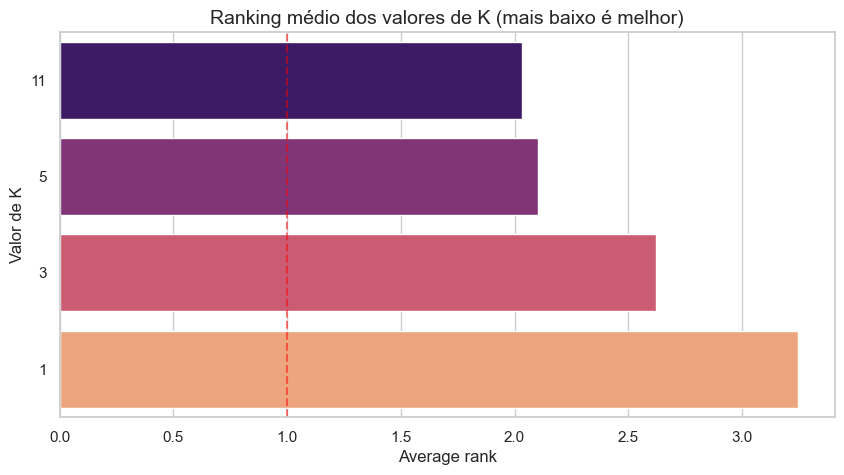

In [9]:
#1 para melhor, 4 para pior
df_ranks = df_final_summary.rank(axis=1, ascending=False)
avg_ranks = df_ranks.mean().sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_ranks.values, y=avg_ranks.index.astype(str), palette='magma')
plt.axvline(1, color='red', linestyle='--', alpha=0.5) 
plt.title('Ranking médio dos valores de K (mais baixo é melhor)', fontsize=14)
plt.xlabel('Average rank')
plt.ylabel('Valor de K')
plt.show()

Os resultados obtidos confirmam a nossa hipótese: o kNN com $k=1$ apresenta, em média, um desempenho inferior e maior variabilidade em datasets ruidosos. À medida que aumentamos o valor de $k$, o modelo torna-se mais resiliente. Esta evidência estatística serve de base para a Phase 2, onde iremos propor uma melhoria (como o LOF - Local Outlier Factor) para limpar estes dados antes mesmo de iniciarmos a classificação, tentando elevar ainda mais a performance nos casos mais críticos.